# VCT 2025 — Exploratory Data Analysis

First pass over the data for the composition-synergy / win-prediction capstone.
Covers checklist steps 2–3 (*get the data*, *explore the data*) from `ML_project_checklist.txt`.

**Scope:** the 2025 season only. 2021–2024 are deliberately out of scope for now — see
section 5 for why (those years have no recoverable match dates, so they can't be
ordered in time without extra work).

**Source:** `ryanluong1/valorant-champion-tour-2021-2023-data` (primary, "Dataset 2")
and `piyush86kumar/valorant-vct-2025-all-events` (dates, "Dataset 1"), both pulled
via `kagglehub` — see `data/README.md`.

**No joins in this notebook.** Everything here is per-table profiling; building the
joined match-level table is the next notebook's job.

### What this notebook establishes

| # | Finding | Consequence |
|---|---------|-------------|
| 3 | `overview.csv` mixes `All Maps` aggregate rows into per-map data | **Must filter** before using it for composition |
| 4 | NRG is recorded as "Mega Minors" in every team column | Needs renaming before any team-level grouping |
| 5 | No date column anywhere in the primary dataset | Dates bridged from Dataset 1 via `src/dates.py` |
| 6 | Five percent columns stored as text (`"91%"`) | Convert before use |
| 8 | ~6 exhibition / all-star matches mixed in | Exclude from modelling |

## Setup

In [1]:
import sys
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
from kagglehub import KaggleDatasetAdapter

sys.path.insert(0, str(Path.cwd().parent / "src"))

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

PRIMARY = "ryanluong1/valorant-champion-tour-2021-2023-data"
YEAR = "vct_2025"

# The full key that identifies a match in the primary dataset.
MATCH_KEY = ["Tournament", "Stage", "Match Type", "Match Name"]


def load(path: str) -> pd.DataFrame:
    """Load one CSV from the primary dataset (kagglehub caches after first pull)."""
    return kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, PRIMARY, f"{YEAR}/{path}")

## 1. Scope — which tables, and why

Ten tables, chosen for the two halves of the project:

**Labels (what we predict)**
- `matches/scores.csv` — match-level result (the Bo3/Bo5 winner)
- `matches/maps_scores.csv` — map-level result

**Pre-match features (known before round 1)**
- `matches/overview.csv` — per-player rows; the `Agents` column is the real source of per-match team composition
- `matches/draft_phase.csv` — map pick/ban sequence
- `agents/maps_stats.csv` — attacker/defender bias per map

**Synergy / meta analysis**
- `agents/teams_picked_agents.csv` — team+map+agent win/loss (stage-aggregated)
- `agents/agents_pick_rates.csv` — baseline agent popularity

**Keys and lookups**
- `ids/tournaments_stages_matches_games_ids.csv` — resolves text keys to Match/Game IDs
- `ids/teams_ids.csv`, `matches/team_mapping.csv`

Deliberately excluded: `eco_*`, `kills*`, `rounds_kills`, `win_loss_methods_*`. These are
round- or duel-level detail describing *how a match played out* — they're match outcomes,
not pre-match state, so they'd leak. Possible stretch goals, not MVP.

In [2]:
TABLES = [
    "ids/tournaments_stages_matches_games_ids.csv",
    "matches/scores.csv",
    "matches/maps_scores.csv",
    "matches/overview.csv",
    "matches/draft_phase.csv",
    "agents/teams_picked_agents.csv",
    "agents/agents_pick_rates.csv",
    "agents/maps_stats.csv",
    "ids/teams_ids.csv",
    "matches/team_mapping.csv",
]

df = {t: load(t) for t in TABLES}

pd.DataFrame(
    [(t, *df[t].shape) for t in TABLES], columns=["table", "rows", "cols"]
).set_index("table")

,rows,cols
table,,
ids/tournaments_stages_matches_games_ids.csv,1277,9
matches/scores.csv,503,9
matches/maps_scores.csv,1277,16
matches/overview.csv,53226,21
matches/draft_phase.csv,2988,7
agents/teams_picked_agents.csv,18396,9
agents/agents_pick_rates.csv,30294,6
agents/maps_stats.csv,1122,7
ids/teams_ids.csv,58,2


## 2. Structural profile — dtypes, nulls, cardinality

In [3]:
def profile(d: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dtype": d.dtypes.astype(str),
            "nulls": d.isna().sum(),
            "null_%": (d.isna().mean() * 100).round(1),
            "nunique": d.nunique(),
        }
    )


profile(df["matches/overview.csv"])

,dtype,nulls,null_%,nunique
Tournament,str,0,0.0,15
Stage,str,0,0.0,5
Match Type,str,0,0.0,39
Match Name,str,0,0.0,359
Map,str,0,0.0,12
Player,str,0,0.0,343
Team,str,0,0.0,56
Agents,str,0,0.0,663
Rating,float64,4080,7.7,317
Average Combat Score,float64,2745,5.2,540


Nulls in `overview.csv` sit at 4.8–7.7% across the performance columns. That matches a
documented limitation in `about_the_dataset.txt`: post-match stats for matches hosted in
China weren't publicly available at scrape time. It is **not** random missingness — it's
concentrated in specific events, which matters if we ever build rolling player-form features.

The identifying columns (`Tournament`, `Stage`, `Match Type`, `Match Name`, `Map`, `Player`,
`Team`, `Agents`) are 100% complete, which is what we actually need for composition.

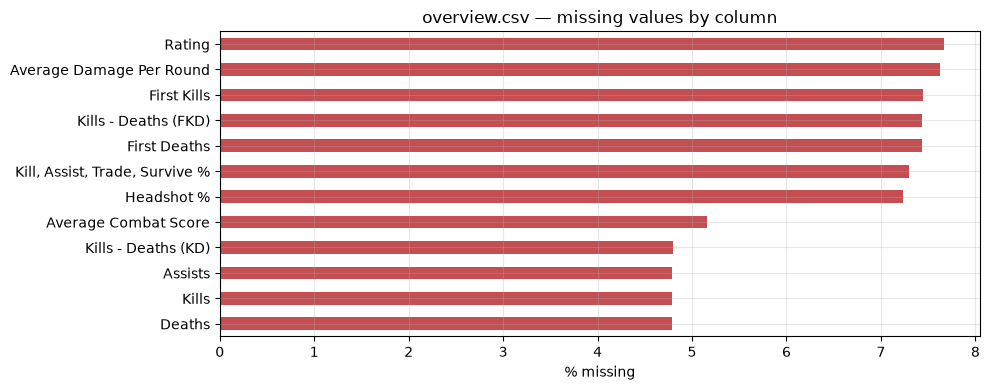

In [4]:
ov_nulls = df["matches/overview.csv"].isna().mean().mul(100)
ov_nulls = ov_nulls[ov_nulls > 0].sort_values()

ax = ov_nulls.plot.barh(color="#c44e52")
ax.set_xlabel("% missing")
ax.set_title("overview.csv — missing values by column")
plt.tight_layout()
plt.show()

In [5]:
# maps_scores: the 88.6% nulls in the overtime columns are expected, not a defect --
# most maps simply never reach overtime.
profile(df["matches/maps_scores.csv"])

,dtype,nulls,null_%,nunique
Tournament,str,0,0.0,15
Stage,str,0,0.0,5
Match Type,str,0,0.0,39
Match Name,str,0,0.0,360
Map,str,0,0.0,11
Team A,str,0,0.0,53
Team A Score,int64,0,0.0,22
Team A Attacker Score,int64,0,0.0,13
Team A Defender Score,int64,0,0.0,12
Team A Overtime Score,float64,1132,88.6,10


## 3. ⚠️ Finding: `overview.csv` mixes aggregate rows into per-map data

This is the single biggest trap in the dataset, and it isn't flagged in the dataset's own
documentation. `overview.csv` contains `All Maps` rollup rows **interleaved with** real
per-map rows.

In [6]:
ov = df["matches/overview.csv"]
ov["Map"].value_counts()

Map
All Maps    14946
Lotus        7050
Haven        5550
Ascent       3750
Icebox       3540
Bind         3240
Split        3120
Pearl        2910
Fracture     2640
Sunset       2520
Corrode      2190
Abyss        1770
Name: count, dtype: int64

14,946 of 53,226 rows (28%) are `All Maps` aggregates.

This also explains an oddity in the `Agents` column: some rows list *multiple* agents
(`"sova, yoru"`), which would look like a player swapping agent mid-map. It isn't —
every multi-agent row is an aggregate row summarising a player across the whole match.

In [7]:
is_all = ov["Map"].str.strip().str.lower() == "all maps"
multi_agent = ov["Agents"].str.contains(",", na=False)

pd.crosstab(
    is_all.map({True: "All Maps row", False: "real map row"}),
    multi_agent.map({True: ">1 agent listed", False: "single agent"}),
    rownames=[""],
    colnames=[""],
)

,>1 agent listed,single agent
,,
All Maps row,11910,3036
real map row,0,38280


Zero real map rows list more than one agent. So filtering `All Maps` fixes the composition
extraction completely — no string-splitting or tie-breaking logic needed.

Once filtered, the table's grain is perfectly regular:

In [8]:
real_maps = ov[~is_all]

rows_per_player = real_maps.groupby(MATCH_KEY + ["Map", "Player"]).size()
players_per_team = (
    real_maps[real_maps["Side"] == "both"]
    .groupby(MATCH_KEY + ["Map", "Team"])["Player"]
    .nunique()
)

print(f"rows per (match, map, player): {rows_per_player.value_counts().to_dict()}")
print(f"  -> 3 = one row each for 'both', 'attack', 'defend'")
print(f"\nplayers per (match, map, team): {players_per_team.value_counts().to_dict()}")
print(f"  -> exactly 5, no exceptions, across {len(players_per_team)} team-maps")

rows per (match, map, player): {3: 12760}
  -> 3 = one row each for 'both', 'attack', 'defend'

players per (match, map, team): {5: 2552}
  -> exactly 5, no exceptions, across 2552 team-maps


> **Rule for every downstream notebook:** filter `Map != "All Maps"` *and* pick a single
> `Side` (use `"both"` for whole-map stats) before touching `overview.csv`. Skipping either
> silently triples row counts and corrupts composition.

## 4. ⚠️ Finding: NRG is recorded as "Mega Minors"

The team columns and the match-name columns disagree with each other about who NRG is.

In [9]:
sc = df["matches/scores.csv"]

name_mismatch = sc[
    ~sc.apply(lambda r: str(r["Team A"]).lower() in str(r["Match Name"]).lower(), axis=1)
]
name_mismatch[["Match Name", "Team A", "Team B", "Match Result"]].head(6)

,Match Name,Team A,Team B,Match Result
2,NRG vs EDward Gaming,Mega Minors,EDward Gaming,NRG won
23,NRG vs GIANTX,Mega Minors,GIANTX,NRG won
33,NRG vs FNATIC,Mega Minors,FNATIC,NRG won
43,NRG vs LOUD,Mega Minors,LOUD,NRG won
67,NRG vs G2 Esports,Mega Minors,G2 Esports,G2 Esports won
70,NRG vs LEVIATÁN,Mega Minors,LEVIATÁN,NRG won


In [10]:
print("Footprint of the 'Mega Minors' alias:")
print(f"  scores.csv matches      : {((sc['Team A'] == 'Mega Minors') | (sc['Team B'] == 'Mega Minors')).sum()}")
print(f"  overview.csv rows       : {(ov['Team'] == 'Mega Minors').sum()}")
print(f"  draft_phase.csv rows    : {(df['matches/draft_phase.csv']['Team'] == 'Mega Minors').sum()}")
print()
teams_ids = df["ids/teams_ids.csv"]
print(f"  'NRG' in teams_ids?         {(teams_ids['Team'] == 'NRG').any()}")
print(f"  'Mega Minors' in teams_ids? {(teams_ids['Team'] == 'Mega Minors').any()}")

Footprint of the 'Mega Minors' alias:
  scores.csv matches      : 25
  overview.csv rows       : 1365
  draft_phase.csv rows    : 75

  'NRG' in teams_ids?         True
  'Mega Minors' in teams_ids? False


So the lookup table knows NRG but not "Mega Minors" — meaning **any join on team name
silently drops all 25 NRG matches**. This is also the sole cause of the 16 rows where a
score-derived winner disagrees with the stated `Match Result`.

Confirmed against the independent Dataset 1, which calls this team "NRG" in all 25
matches and never once uses the string "Mega Minors" — so this is a safe rename, not a guess.

In [11]:
TEAM_ALIASES = {"Mega Minors": "NRG"}


def normalise_teams(d: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Resolve known team aliases so name-based grouping and joins behave."""
    d = d.copy()
    for c in cols:
        d[c] = d[c].replace(TEAM_ALIASES)
    return d


check = normalise_teams(sc, ["Team A", "Team B"])
still_bad = check[
    ~check.apply(lambda r: str(r["Team A"]).lower() in str(r["Match Name"]).lower(), axis=1)
]
print(f"team/match-name mismatches after normalising: {len(still_bad)} (was {len(name_mismatch)})")

team/match-name mismatches after normalising: 0 (was 11)


## 5. Finding: the primary dataset has no dates

A chronological train/test split is what stops meta/patch leakage — training on September
matches and testing on March ones would inflate accuracy meaninglessly. That requires
ordering matches in time.

**None of the primary dataset's 21 tables contains a date column.** Dates come instead
from Dataset 1, which shares a vlr.gg match ID space with it. `src/dates.py` builds that
bridge; see `data/README.md` for the details and the two parsing traps it handles.

In [12]:
from dates import load_match_dates

dates = load_match_dates()
ids = df["ids/tournaments_stages_matches_games_ids.csv"]

covered = set(ids["Match ID"]) & set(dates["match_id"])
print(f"matches in primary dataset : {ids['Match ID'].nunique()}")
print(f"of those, dated            : {len(covered)} ({len(covered) / ids['Match ID'].nunique():.1%})")
print(f"season spans               : {dates['match_date'].min().date()} -> {dates['match_date'].max().date()}")
dates.head()

matches in primary dataset : 503
of those, dated            : 503 (100.0%)
season spans               : 2025-01-11 -> 2025-10-05


,match_id,match_date,match_datetime,event,stage,week
0,430838,2025-01-11,2025-01-11 14:30:00,VCT 2025 China Kickoff,Main Event,Upper Round 1
1,430837,2025-01-11,2025-01-11 17:05:00,VCT 2025 China Kickoff,Main Event,Upper Round 1
2,430839,2025-01-12,2025-01-12 14:30:00,VCT 2025 China Kickoff,Main Event,Upper Round 1
3,430840,2025-01-12,2025-01-12 17:55:00,VCT 2025 China Kickoff,Main Event,Upper Round 1
4,429381,2025-01-15,2025-01-15 22:30:00,VCT 2025 EMEA Kickoff,Main Event,Upper Round 1


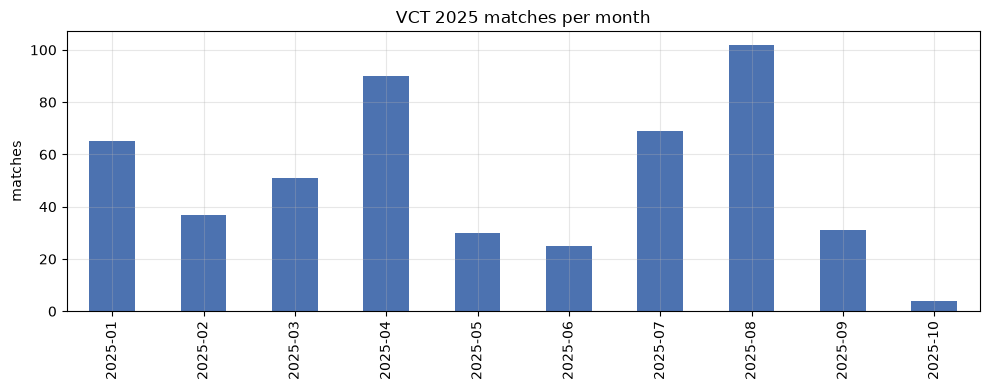

In [13]:
monthly = dates.groupby(dates["match_date"].dt.to_period("M")).size()

ax = monthly.plot.bar(color="#4c72b0")
ax.set_ylabel("matches")
ax.set_xlabel("")
ax.set_title("VCT 2025 matches per month")
plt.tight_layout()
plt.show()

In [14]:
# The season has a clean event structure -- useful because a split on an event
# boundary avoids cutting a single tournament across train and test.
calendar = (
    dates.groupby("event")
    .agg(first=("match_date", "min"), last=("match_date", "max"), matches=("match_id", "size"))
    .sort_values("first")
)
calendar

,first,last,matches
event,,,
VCT 2025 China Kickoff,2025-01-11,2025-01-25,22
VCT 2025 EMEA Kickoff,2025-01-15,2025-02-09,22
VCT 2025 Americas Kickoff,2025-01-17,2025-02-09,22
VCT 2025 Pacific Kickoff,2025-01-18,2025-02-09,22
Valorant Masters Bangkok 2025,2025-02-20,2025-03-02,17
VCT 2025 China Stage 1,2025-03-13,2025-05-04,42
VCT 2025 Americas Stage 1,2025-03-22,2025-05-05,42
VCT 2025 Pacific Stage 1,2025-03-22,2025-05-11,42
VCT 2025 EMEA Stage 1,2025-03-26,2025-05-18,42


The calendar matches the real VCT season (Kickoffs → Masters Bangkok → Stage 1 →
Masters Toronto → Stage 2 → Champions), which is a good independent sanity check that
the dates parsed correctly.

A natural split point is **after Masters Toronto (2025-06-22)**: train on everything up to
and including it, test on Stage 2 + Champions. No tournament straddles the boundary, and
the test set sits in a genuinely later meta.

## 6. Finding: percent columns are stored as text

Five columns hold strings like `"91%"` rather than numbers, so they'd sort and aggregate
wrongly (and silently) if used as-is.

In [15]:
def find_percent_columns(d: pd.DataFrame, name: str) -> list[tuple[str, str, str]]:
    found = []
    for c in d.columns:
        if d[c].dtype.kind in "ifb":
            continue
        vals = d[c].dropna().astype(str).str.strip()
        if vals.empty or vals.str.endswith("%").mean() <= 0.5:
            continue
        found.append((name, c, ", ".join(vals.unique()[:3])))
    return found


pct_cols = [
    row
    for t in TABLES
    for row in find_percent_columns(df[t], t.split("/")[-1])
]
pd.DataFrame(pct_cols, columns=["table", "column", "examples"])

,table,column,examples
0,overview.csv,"Kill, Assist, Trade, Survive %","91%, 100%, 83%"
1,overview.csv,Headshot %,"15%, 16%, 13%"
2,agents_pick_rates.csv,Pick Rate,"95%, 60%, 55%"
3,maps_stats.csv,Attacker Side Win Percentage,"62%, 56%, 67%"
4,maps_stats.csv,Defender Side Win Percentage,"38%, 44%, 33%"


In [16]:
def pct_to_float(s: pd.Series) -> pd.Series:
    """'91%' -> 0.91. Returns NaN for missing values rather than raising."""
    return pd.to_numeric(s.astype(str).str.rstrip("%"), errors="coerce") / 100


kast = pct_to_float(ov["Kill, Assist, Trade, Survive %"])
print(f"KAST as float -> min={kast.min():.2f}  median={kast.median():.2f}  max={kast.max():.2f}")

KAST as float -> min=0.09  median=0.73  max=1.00


## 7. The data we actually care about: maps and agents

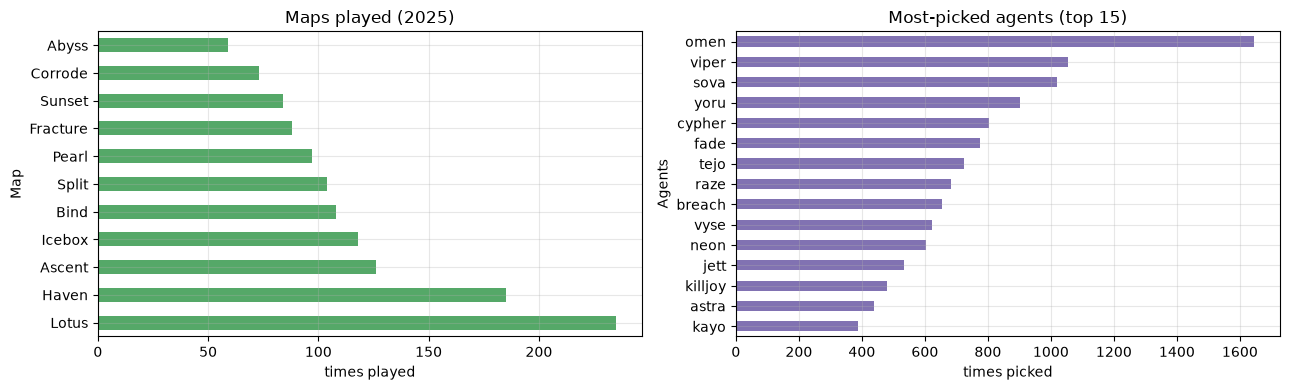

In [17]:
ms = df["matches/maps_scores.csv"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ms["Map"].value_counts().plot.barh(ax=axes[0], color="#55a868")
axes[0].set_title("Maps played (2025)")
axes[0].set_xlabel("times played")

agent_counts = (
    real_maps[real_maps["Side"] == "both"]["Agents"].value_counts().head(15).sort_values()
)
agent_counts.plot.barh(ax=axes[1], color="#8172b2")
axes[1].set_title("Most-picked agents (top 15)")
axes[1].set_xlabel("times picked")

plt.tight_layout()
plt.show()

In [18]:
# Composition = the 5 agents a team fielded on a map. Sanity-check that this is
# well-formed before relying on it as a feature (no joins -- single table).
comps = (
    real_maps[real_maps["Side"] == "both"]
    .groupby(MATCH_KEY + ["Map", "Team"])["Agents"]
    .apply(lambda s: tuple(sorted(s)))
)

print(f"team-map compositions      : {len(comps)}")
print(f"all exactly 5 agents?      : {comps.map(len).eq(5).all()}")
print(f"distinct compositions      : {comps.nunique()}")
print(f"compositions used only once: {(comps.value_counts() == 1).sum()}")
print()
print("Most common compositions:")
comps.value_counts().head(5)

team-map compositions      : 2552
all exactly 5 agents?      : True
distinct compositions      : 465
compositions used only once: 168

Most common compositions:


Agents
(fade, omen, raze, viper, vyse)       86
(breach, omen, tejo, viper, yoru)     81
(breach, cypher, neon, omen, sova)    78
(cypher, iso, omen, sova, yoru)       70
(cypher, jett, kayo, omen, sova)      62
Name: count, dtype: int64

Composition extraction works cleanly — every team-map yields exactly 5 agents.

Note the long tail: most compositions appear only a handful of times. That's the central
difficulty for the synergy half of the project, and it means treating a full 5-agent comp
as a single categorical feature won't generalise. Agent *pairs* or per-agent indicators
are likely to work better.

## 8. Finding: exhibition matches are mixed in

The season data includes all-star and showmatch exhibitions alongside real competitive
matches. These are explicitly labelled with `Stage == "Showmatch"`.

In [19]:
exhibition = sc[sc["Stage"] == "Showmatch"]
exhibition[["Tournament", "Stage", "Match Type", "Match Name", "Match Result"]]

,Tournament,Stage,Match Type,Match Name,Match Result
74,VCT 2025: Americas Stage 2,Showmatch,Override,Team Alpha vs Team Omega,Team Alpha won
118,VCT 2025: EMEA Stage 2,Showmatch,Main Event,Team France vs Team EMEA,Team EMEA won
160,VCT 2025: Pacific Stage 2,Showmatch,Main Event,Team World vs Glory Once Again,Team World won
201,VCT 2025: China Stage 2,Showmatch,All-Star Match,Pure Aim vs Precise Defeat,Precise Defeat won
413,Valorant Masters Bangkok 2025,Showmatch,Main Event,Team International vs Team Thailand,Team Thailand won


In [20]:
# Corroborate with an independent signal: exhibition line-ups are ad-hoc, so each
# should appear in exactly one match. Agreement between two unrelated signals is
# much stronger evidence than either alone.
appearances = pd.concat([sc["Team A"], sc["Team B"]]).value_counts()
one_off = set(appearances[appearances == 1].index)
by_one_off = sc[sc["Team A"].isin(one_off) | sc["Team B"].isin(one_off)]

print(f"flagged by Stage == 'Showmatch' : {len(exhibition)}")
print(f"flagged by one-off team names   : {len(by_one_off)}")
print(f"the two agree exactly           : {set(exhibition.index) == set(by_one_off.index)}")

flagged by Stage == 'Showmatch' : 5
flagged by one-off team names   : 5
the two agree exactly           : True


These should be excluded from modelling: the "teams" don't exist outside these fixtures,
so they carry no transferable signal and would pollute team-level history features.

This also explains the one match present in `scores.csv` but absent from `overview.csv`
(the Bangkok showmatch) — a coverage gap that turns out to be harmless.

## 9. Label sanity

Before modelling anything, confirm the target variable is clean.

In [21]:
print(f"matches                      : {len(sc)}")
print(f"draws / unplayed (A == B)    : {(sc['Team A Score'] == sc['Team B Score']).sum()}")
print(f"score dtypes                 : {sc['Team A Score'].dtype}, {sc['Team B Score'].dtype}")
print(f"nulls in scores              : {sc[['Team A Score', 'Team B Score']].isna().sum().sum()}")
print()

# Class balance: is 'Team A' systematically favoured? (It shouldn't be -- A/B is
# just listing order, so a strong imbalance would signal a recording artefact.)
a_wins = (sc["Team A Score"] > sc["Team B Score"]).mean()
print(f"Team A win rate              : {a_wins:.1%}")
print("  -> near 50% means A/B ordering carries no hidden signal, as expected")

matches                      : 503
draws / unplayed (A == B)    : 0
score dtypes                 : int64, int64
nulls in scores              : 0

Team A win rate              : 53.3%
  -> near 50% means A/B ordering carries no hidden signal, as expected


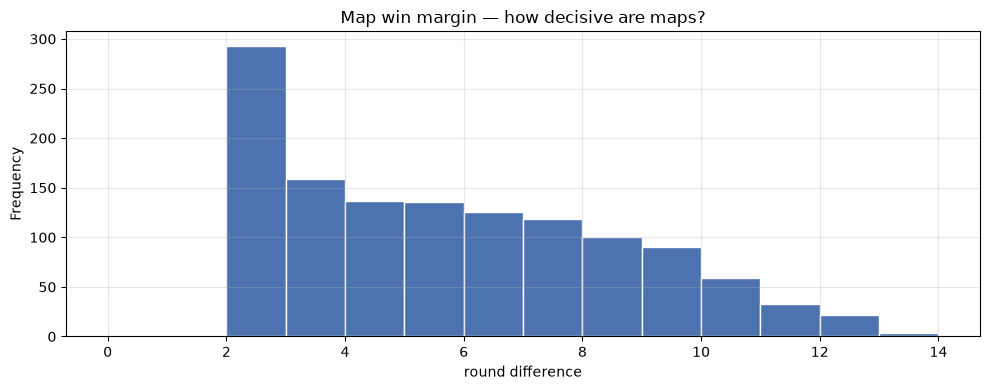

maps decided by <= 2 rounds: 22.9%


In [22]:
margin = (ms["Team A Score"] - ms["Team B Score"]).abs()

ax = margin.plot.hist(bins=range(0, 15), color="#4c72b0", edgecolor="white")
ax.set_xlabel("round difference")
ax.set_title("Map win margin — how decisive are maps?")
plt.tight_layout()
plt.show()

print(f"maps decided by <= 2 rounds: {(margin <= 2).mean():.1%}")

## 10. Summary — decisions carried into feature engineering

**Cleaning rules (all verified above, none optional):**
1. Filter `Map != "All Maps"` and `Side == "both"` on `overview.csv` before anything else.
2. Apply `TEAM_ALIASES` (`Mega Minors` → `NRG`) before any team-level grouping or join.
3. Convert the five percent columns with `pct_to_float`.
4. Drop the ~6 exhibition matches.
5. Attach dates via `src/dates.py`; order by `(match_datetime, match_id)`, never by `match_id` alone.

**Modelling implications:**
- **Model at map level, not match level.** 1,277 map rows vs 503 match rows — and
  composition is chosen *per map*, so it's the grain the question is actually asked at.
- **Split on an event boundary**, training up to Masters Toronto and testing on
  Stage 2 + Champions.
- **Don't treat a full 5-agent comp as one category** — the long tail means most comps
  appear only a few times. Per-agent indicators or agent pairs will generalise better.
- **Exclude all in-match performance columns** (Rating, ACS, KAST, ADR, HS%, …) from
  features. They describe how the match went, so they leak the result. They're only
  usable as rolling history built from a team's or player's *earlier* matches.

**Next:** build the joined map-level table — composition + map + draft + label — applying
these rules, and verify the join doesn't drop rows.